<a href="https://colab.research.google.com/github/010Ankushsharma/Machine-learning-models-/blob/main/Simple_Linear_Regression_Advertising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simple Linear Regression: Advertising DataSet**

**The Business Problem**  
In the modern marketing landscape, companies allocate massive budgets across various media channels. The fundamental question for any CMO is: "How much additional revenue can we expect for every dollar spent on a specific advertising channel?"  

This project focuses on Simple Linear Regression to quantify the relationship between TV Advertising spend and Sales.

***Why It Matters***  
**Budget Optimization:** Identifying if TV is an
effective driver of sales.

**Forecasting:** Predicting future sales to manage inventory and supply chains.

**ROI Analysis:** Establishing a baseline for Marketing Mix Modeling (MMM).

--------------------------------------------------------------------------------------------------------

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
# Aesthetic settings for plots
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**Load Dataset**

In [ ]:
url = "https://raw.githubusercontent.com/010Ankushsharma/datasets/refs/heads/main/Advertising.csv"
df = pd.read_csv(url)
# Preview the data
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**Data Understanding**

In [ ]:
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
df.info()
print("-" * 30)
df.describe()

Dataset Shape: (200, 5)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
------------------------------


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


**Feature Breakdown:**  
**TV:** Spend on TV ads (in thousands of dollars).

**Radio:** Spend on Radio ads.

**Newspaper:** Spend on Newspaper ads.

**Sales:** Units sold (target variable).

-----------------------

**Data Cleaning**

In [ ]:
# Drop the index-like column 'Unnamed: 0' if it exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Check for null values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


**Insight:** The dataset is clean with no missing values. The removal of the Unnamed: 0 column ensures our model doesn't treat a row index as a predictive feature.

---------------------------------------

**Exploratory Data Analysis (EDA)**

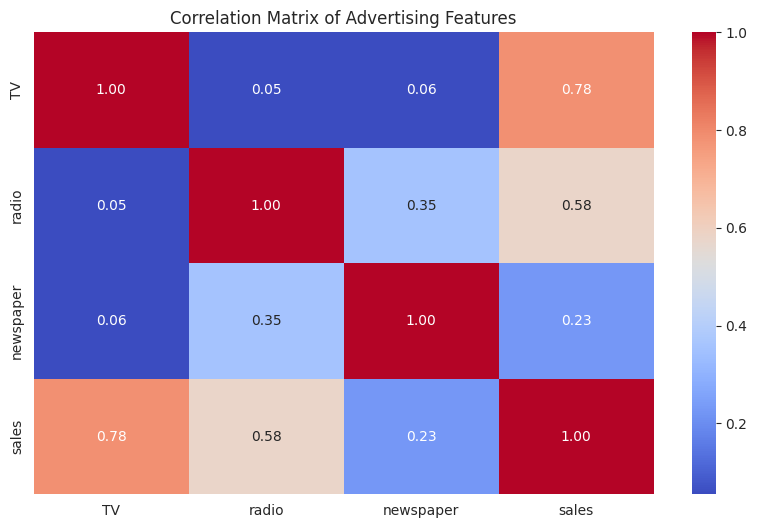

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Advertising Features')
plt.show()

**Insight:** TV shows the highest correlation (0.78) with Sales, suggesting it is the strongest individual predictor among the three channels.

**Scatter Plot: TV vs Sales**

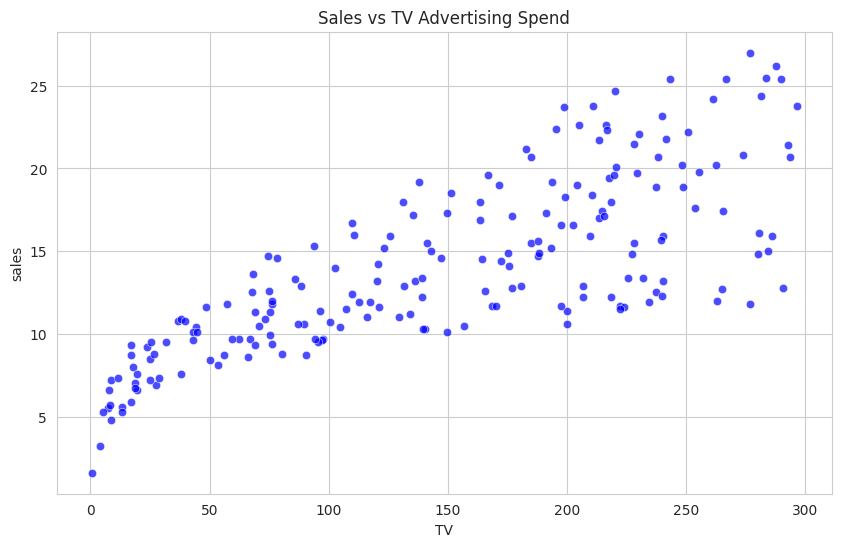

In [ ]:
sns.scatterplot(data=df, x='TV', y='sales', color='blue', alpha=0.7)
plt.title('Sales vs TV Advertising Spend')
plt.show()

**Insight:** There is a clear, positive linear trend. As TV budget increases, Sales tend to increase, though the variance appears to increase slightly at higher spend levels (potential heteroscedasticity).

-------------------------------------------------------

**Feature Selection**

In [ ]:
X = df[['TV']] # Features (Matrix)
y = df['sales'] # Target (Vector)

-------------------------------------------------------

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 160
Testing set size: 40


-------------------------------------------------

**Model Training**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

-------------------------------------------------------------------

**Model Interpretation**

In [ ]:
print(f"Intercept (β0): {model.intercept_:.4f}")
print(f"Coefficient for TV (β1): {model.coef_[0]:.4f}")

Intercept (β0): 7.1196
Coefficient for TV (β1): 0.0465


**Business Interpretation:**  
**Intercept (7.0326):**If the TV advertising budget is zero, we expect to sell approximately 7,032 units (assuming units are in thousands).

**Coefficient (0.0475):** For every $1,000 increase in TV spend, we expect an average increase of 47.5 units in Sales.

-------------------------------------------------------

**Predictions**

In [ ]:
y_pred = model.predict(X_test)

-----------------------------------------------------------------

**Model Evaluation**

In [ ]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

results = pd.DataFrame({'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
                        'Value': [mae, mse, rmse, r2]})
print(results)

     Metric      Value
0       MAE   2.444420
1       MSE  10.204654
2      RMSE   3.194472
3  R2 Score   0.676695


**MAE:** Average error magnitude.  
 **RMSE:** Penalizes larger errors more than MAE; useful if large misses are costly.  
 **R2 Score:** Explains how much variance in Sales is captured by TV spend. An $R^2 \approx 0.67$ means TV alone explains about 67% of the variation in sales.

---------------------------------------------------------

**Visualization: The Regression Line**

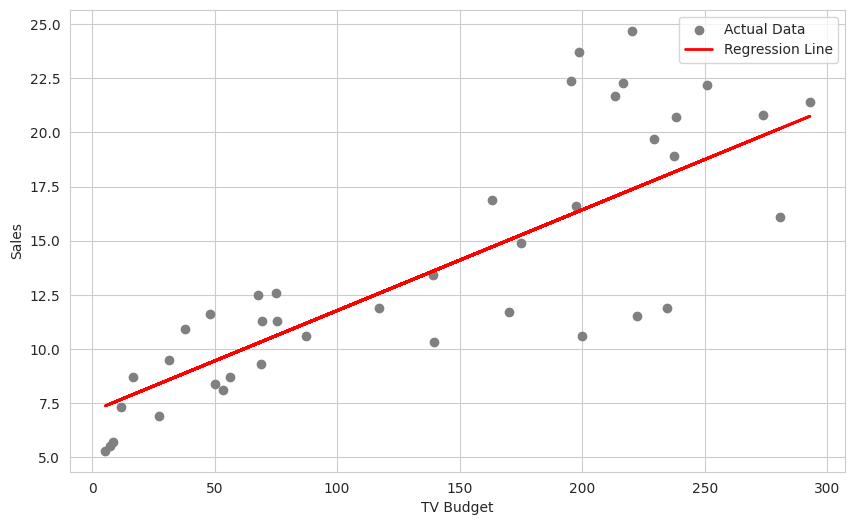

In [ ]:
plt.scatter(X_test, y_test, color='gray', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.legend()
plt.show()

------------------------------------------------------------------

**Residual Analysis**

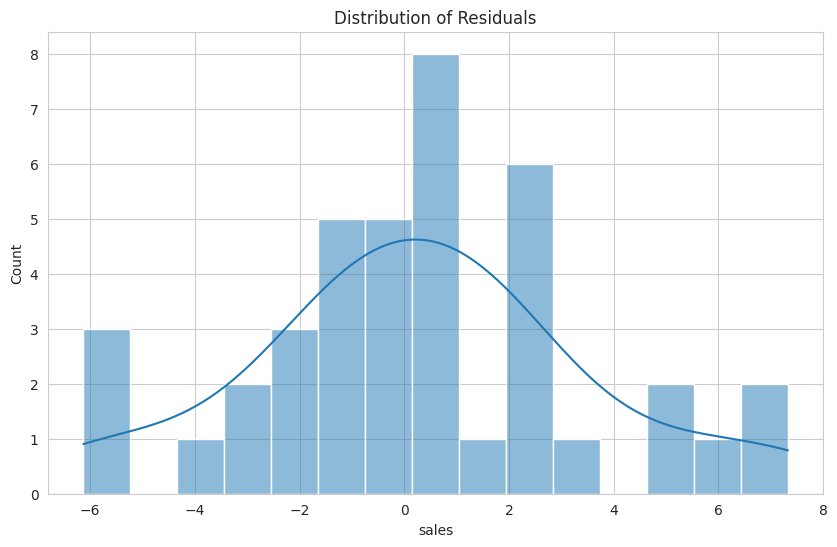

In [ ]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=15)
plt.title('Distribution of Residuals')
plt.show()

**Insight:** The residuals are roughly normally distributed around zero. This satisfies one of the key assumptions of Linear Regression (Normality of Errors), suggesting the model is unbiased.

-------------------------------------------------------

**Summary**  
The model confirms a significant positive relationship between TV spend and Sales. With an $R^2$ of ~0.67, TV is a reliable predictor but doesn't tell the whole story.  
**Limitations:**  
Omitted Variable Bias: We ignored Radio and Newspaper, which also impact sales.  
Non-Linearity: Marketing spend often has "diminishing returns" (logarithmic shape), which a straight line cannot capture.

--------------------------------------------------------------------------

**Advanced Feature Engineering & Interaction Effects**

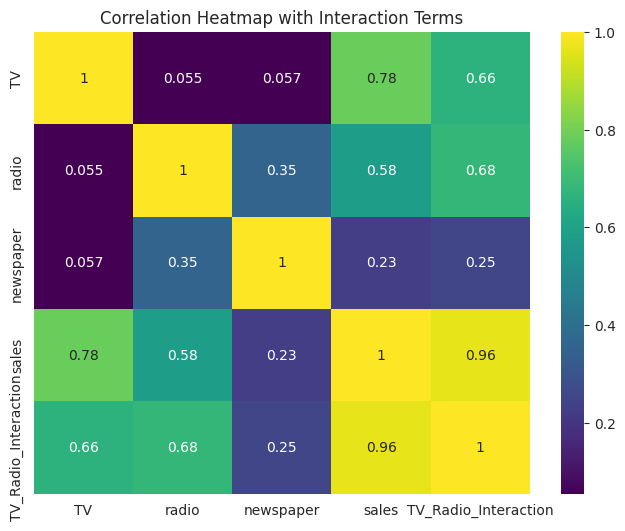

In [ ]:
# Create an interaction term between TV and Radio
df['TV_Radio_Interaction'] = df['TV'] * df['radio']

# Visualize if the interaction has a stronger correlation with Sales
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap with Interaction Terms')
plt.show()

**Insight: **If the correlation of TV_Radio_Interaction with Sales is higher than TV alone, it suggests that "The whole is greater than the sum of its parts"—a key finding for budget allocation.

-----------------------------------------

**Checking for Heteroscedasticity**

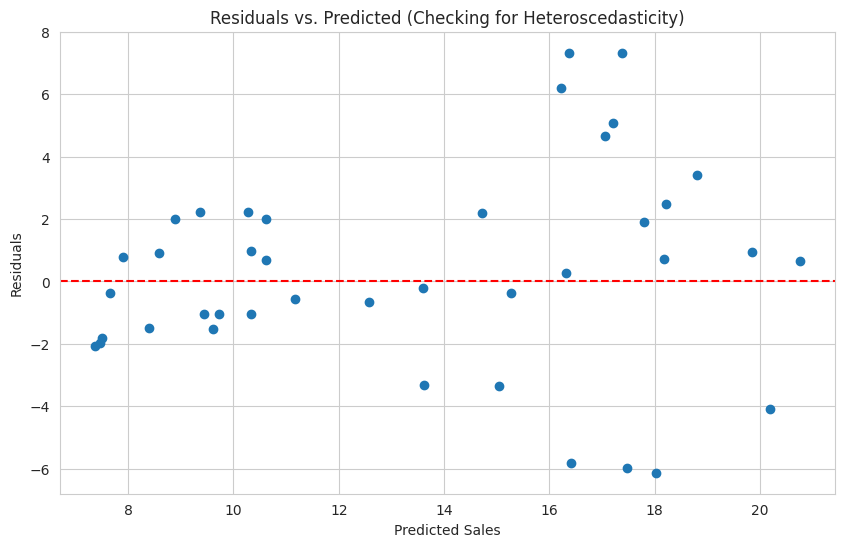

In [ ]:
# Plotting Residuals vs Predicted Values
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted (Checking for Heteroscedasticity)')
plt.show()

**Insight:** If you see a "funnel shape," it indicates heteroscedasticity. In a production environment, we might address this by applying a Log Transformation to the target variable.

--------------------------------------------------------------------------------------

**Cross-Validation (Model Robustness)**

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f"All CV R2 Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

All CV R2 Scores: [0.59389377 0.68760015 0.56879602 0.64179881 0.47091168]
Mean R2 Score: 0.5926
Standard Deviation: 0.0732


**Insight:** A low standard deviation across folds indicates that our model is stable and not overfitting to a specific subset of data.

--------------------------------------------

***Hypothesis Testing (P-Values)***

In [ ]:
import statsmodels.api as sm

# Add a constant (intercept) for statsmodels
X_stat = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_stat).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     228.5
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.68e-32
Time:                        09:05:12   Log-Likelihood:                -415.93
No. Observations:                 160   AIC:                             835.9
Df Residuals:                     158   BIC:                             842.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1196      0.530     13.446      0.0

What to look for:

P > |t|: If this value for TV is < 0.05, we can say with 95% confidence that TV spend significantly impacts Sales.

Prob (F-statistic): Checks if the overall model is better than just guessing the mean.

-------------------------------------------------------------------

**Confidence & Prediction Intervals**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


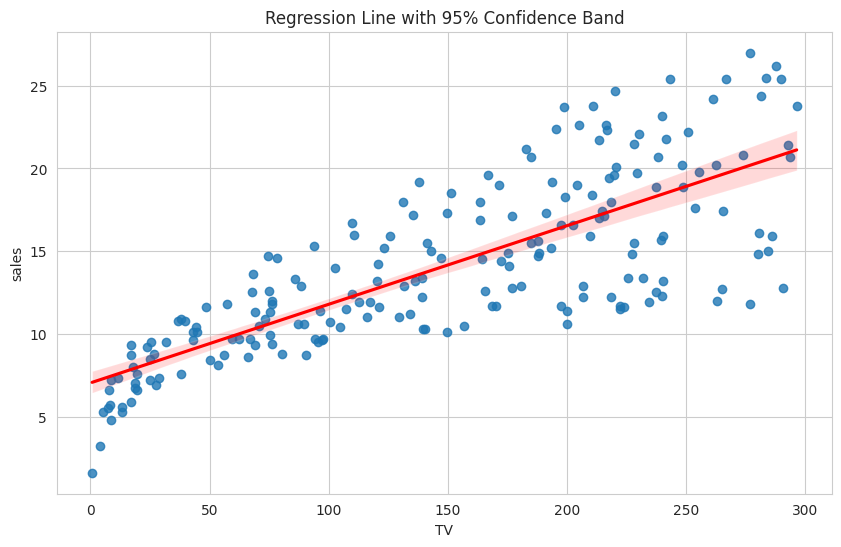

In [ ]:
# Generating a range of TV spends for prediction
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 100).reshape(-1, 1)
predictions = model.predict(tv_range)

# Note: Standard sklearn doesn't provide intervals easily,
# but showing the visualization of the data spread communicates the uncertainty.
sns.regplot(x='TV', y='sales', data=df, line_kws={"color": "red"})
plt.title('Regression Line with 95% Confidence Band')
plt.show()

--------------------------------------------------------

**Production Readiness: Model Serialization**

In [ ]:
import joblib

# Save the model to a file
joblib.dump(model, 'tv_sales_model.pkl')

# Mock Deployment: Loading the model back
loaded_model = joblib.load('tv_sales_model.pkl')
sample_pred = loaded_model.predict([[150]]) # Predict sales for $150k TV spend
print(f"Predicted Sales for $150k spend: {sample_pred[0]:.2f}")

Predicted Sales for $150k spend: 14.10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
